| Roll No.| Subject Code | Assignment No. |
|:-------:|:------------:|:--------------:|
| 2650026 | CS69101      | Lab 3          |

To construct an AVL Tree for a given set of elements stored in a file, implement insertion and deletion operations on the constructed tree, and write the contents of the tree (after these operations) into a new file using in-order traversal.

Prerequisite Code Section
----------------------------

In [1]:
import sys
from io import TextIOWrapper
from typing import Self
import random
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import figure

sys.setrecursionlimit(100000) # Fix to avoid RecursionError

prep_arr = [random.randint(1, (i+1)*10) for i in range(5000)] # Random Array of 5000 Elements
# prep_arr.sort() # Sorted Array for Worst Case Scenario
print(prep_arr[:25])
print(len(prep_arr))

# Write the array to a file
f = open("input0.txt", "w")
for i in prep_arr:
    f.write(f"{i}, ")
f.write("\n")
f.close()

del prep_arr
del f

iterations = 0
PRINT_DEBUG = False

[7, 4, 26, 28, 47, 4, 22, 55, 27, 62, 2, 10, 9, 75, 95, 18, 127, 78, 111, 72, 177, 100, 61, 230, 219]
5000


# Q1

Read a set of integer elements from an input file `(input.txt)`.

In [2]:
# Read a set of integer elements from an input file (input.txt)
arr0 = []
data0 = open("input.txt", 'r')

try:
    for line in data0.readlines():
        line_data = line.rstrip().rstrip(',').replace(' ','').split(',') #using rstrip to remove the \n
        for data in line_data:
            arr0.append(int(data))
    data0.close()
except Exception as e:
    sys.exit("[ERROR] Invalid data" + str(e))

In [3]:
print(arr0)

[70, 50, 90, 77, 55]


# Q2 & Q3

Construct a balanced AVL tree by inserting these elements one by one, performing the necessary LL, RR, LR, RL rotations to maintain balance after every insertion.

Implement an insert(key) operation that adds a new node to the AVL tree while preserving
the AVL balance property $$ ( \, \text{balance factor} \in \{ -1, 0, 1 \} \text{ for every node} ) \,. $$

In [4]:
class AVL_Node: # AVL Node class
    def __init__(self):
        self.__lchild = None
        self.__rchild = None
        self.__value = None
        self.__parent = None
        self.__height = None
        self.__balance_factor = None

    def update_height_and_balance(self) -> None:
        # Print statement for debugging
        if PRINT_DEBUG:
            print(f"Updating height and balance factor for node with value: {self.__value}")
            print(f"Left child: {self.__lchild}, Right child: {self.__rchild}")
        self.__height = 1 + max(
            int(-1 if self.__lchild is None else self.__lchild.__get_height()), # type: ignore
            int(-1 if self.__rchild is None else self.__rchild.__get_height()) # type: ignore
        )
        if PRINT_DEBUG:
            print(f"Updated height: {self.__height}")
        self.__balance_factor = (
            (-1 if self.__lchild is None else int(self.__lchild.__get_height())) -
            (-1 if self.__rchild is None else int(self.__rchild.__get_height()))
        ) # type: ignore
        if PRINT_DEBUG:
            print(f"Updated balance factor: {self.__balance_factor}")
        return

    def __get_height(self) -> int:
        # temp_lchild = self.__lchild
        # temp_rchild = self.__rchild
        # temp_lchild_height = -1
        # temp_rchild_height = -1
        # if temp_lchild is not None:
        #     temp_lchild_height = temp_lchild.__get_height()
        # if temp_rchild is not None:
        #     temp_rchild_height = temp_rchild.__get_height()
        # # if self.__height is None:
        # self.__height = 1 + max(temp_lchild_height, temp_rchild_height)
        
        # Update the height if None
        if self.__height is None:
            self.update_height_and_balance()
        # print(f"Node value: {self.__value}, Left child height: {temp_lchild_height}, Right child height: {temp_rchild_height}, Node height: {self.__height}")
        return 0 if self.__height is None else self.__height

    def __set_height(self, height: int) -> None:
        self.__height = height

    height = property(__get_height, __set_height, doc="Height of the node")

    def __get_balance_factor(self) -> int:
        return 0 if self.__balance_factor is None else self.__balance_factor

    def __set_balance_factor(self, balance_factor: int) -> None:
        self.__balance_factor = balance_factor

    balance_factor = property(__get_balance_factor, __set_balance_factor, doc="Balance factor of the node")

    def __get_lchild(self) -> Self | None:
        return self.__lchild

    def __set_lchild(self, lchild: Self | None) -> None: # type: ignore
        if PRINT_DEBUG:
            print(f"Setting left child of node with value {self.__value} to {lchild}")
        self.__lchild = lchild
        if lchild is not None:
            lchild.__parent = self
            lchild.update_height_and_balance()  # Update the height and balance factor of the left child when it is set
        self.update_height_and_balance()  # Update the height and balance factor of the current node when the left child is set

    lchild = property(__get_lchild, __set_lchild, doc="Left child of the node")

    def __get_rchild(self) -> Self | None:
        return self.__rchild

    def __set_rchild(self, rchild: Self | None) -> None: # type: ignore
        if PRINT_DEBUG:
            print(f"Setting right child of node with value {self.__value} to {rchild}")
        self.__rchild = rchild
        if rchild is not None:
            rchild.__parent = self
            rchild.update_height_and_balance()  # Update the height and balance factor of the right child when it is set
        self.update_height_and_balance()  # Update the height and balance factor of the current node when the right child is set

    rchild = property(__get_rchild, __set_rchild, doc="Right child of the node")

    def __get_parent(self) -> Self | None:
        return self.__parent

    def __set_parent(self, parent: Self | None) -> None: # type: ignore
        if PRINT_DEBUG:
            print(f"Setting parent of node with value {self.__value} to {parent}")
        self.__parent = parent
        if parent is not None:
            parent.update_height_and_balance()  # Update the height and balance factor of the parent when it is set

    parent = property(__get_parent, __set_parent, doc="Parent of the node")

    def __get_value(self) -> int | None:
        return self.__value

    def __set_value(self, value: int) -> None:
        self.__value = value

    value = property(__get_value, __set_value, doc="Value of the node")

    def __str__(self) -> str:
        return f"Node(value={self.__value}, height={self.__height}, balance_factor={self.__balance_factor})"

    def __repr__(self) -> str:
        return self.__str__()

def AVL_right_rotate(k2_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Right Rotate: k2_node={k2_node}, root_node={root_node}")
    k1_node = k2_node.lchild if k2_node is not None else None
    if k1_node is None or k2_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"LL Case: k1_node={k1_node}, k2_node={k2_node}")

    # From Weiss' Data Structures and Algorithm Analysis in C++ (Page 156)
    # Combined CLRS Logic with Weiss' Logic to avoid bugs
    
    # SAFETY CODE
    TEMP_NODE = k1_node.rchild
    OG_PARENT = k2_node.parent
    WAS_RCHILD = bool(OG_PARENT is not None and OG_PARENT.rchild is k2_node)

    # CLRS: x.lchild = y.rchild
    # CLRS: y.rchild = x
    k1_node.rchild = k2_node
    k2_node.lchild = TEMP_NODE

    # Update Parents

    # CLRS: if y.rchild is not None:
    # CLRS:     y.rchild.parent = y
    # CLRS: // However, y.rchild is now x.lchild, so we need to update x.lchild's parent to y
    if PRINT_DEBUG:
        print(f"Updating parent of {k2_node.lchild} to {k2_node}")
    if k2_node.lchild is not None:
        k2_node.lchild.parent = k2_node

    # CLRS: x.parent = y.parent
    k1_node.parent = OG_PARENT

    # CLRS: if y.parent is None:
    # CLRS:     root_node = y
    if OG_PARENT is None:
        # root_node = k1_node
        pass # The input node will always be the root_node for the called function.
    # CLRS: elseif y is y.parent.rchild:
    # CLRS:     y.parent.rchild = x
    elif WAS_RCHILD:
        OG_PARENT.rchild = k1_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT
    # CLRS: else:
    # CLRS:     y.parent.lchild = x
    else:
        OG_PARENT.lchild = k1_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT

    root_node = k1_node # The input node will always be the root_node for the called function.

    # CLRS: y.parent = x
    # k2_node.parent = k1_node (THIS IS AUTO HANDLED BY SETTER METHOD)

    # if k1_node.rchild is not None:
    #     k1_node.rchild.parent = k1_node

    # root_node = k1_node if OG_PARENT is None else root_node // Copilot told me this

    k1_node.update_height_and_balance() # Update height and balance factor of k1_node
    k2_node.update_height_and_balance() # Update height and balance factor of k2_node

    if k1_node.parent is not None:
        k1_node.parent.update_height_and_balance() # Update height and balance factor of k1_node's parent

    return root_node

def AVL_left_rotate(k1_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Left Rotate: k1_node={k1_node}, root_node={root_node}")
    k2_node = k1_node.rchild if k1_node is not None else None
    if k1_node is None or k2_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"RR Case: k1_node={k1_node}, k2_node={k2_node}")

    # From Weiss' Data Structures and Algorithm Analysis in C++ (Page 156)
    # Combined CLRS Logic with Weiss' Logic to avoid bugs
    
    # SAFETY CODE
    TEMP_NODE = k2_node.lchild
    OG_PARENT = k1_node.parent
    WAS_RCHILD = bool(OG_PARENT is not None and OG_PARENT.rchild is k1_node)

    # CLRS: x.rchild = y.lchild
    # CLRS: y.lchild = x
    k2_node.lchild = k1_node
    k1_node.rchild = TEMP_NODE

    # Update Parents

    # CLRS: if y.lchild is not None:
    # CLRS:     y.lchild.parent = x
    # CLRS: // However, y.lchild is now x.rchild, so we need to update x.rchild's parent to y
    if k1_node.rchild is not None:
        k1_node.rchild.parent = k1_node

    # CLRS: y.parent = x.parent
    k2_node.parent = OG_PARENT

    # CLRS: if x.parent is None:
    # CLRS:     root_node = y
    if OG_PARENT is None:
        # root_node = k2_node
        pass # The input node will always be the root_node for the called function.
    # CLRS: elseif x is x.parent.lchild:
    # CLRS:     x.parent.lchild = y
    elif WAS_RCHILD:
        OG_PARENT.rchild = k2_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT
    # CLRS: else:
    # CLRS:     x.parent.rchild = y
    else:
        OG_PARENT.lchild = k2_node
        OG_PARENT.update_height_and_balance() # Update height and balance factor of OG_PARENT

    root_node = k2_node

    # CLRS: x.parent = y
    # k1_node.parent = k2_node (THIS IS AUTO HANDLED BY SETTER METHOD)
    
    k1_node.update_height_and_balance() # Update height and balance factor of k1_node
    k2_node.update_height_and_balance() # Update height and balance factor of k2_node

    if k2_node.parent is not None:
        k2_node.parent.update_height_and_balance() # Update height and balance factor of k2_node's parent

    return root_node

#   k3
#   /
# k1          =>        k2
#  \                   / \
#   k2                k1 k3
    
def AVL_double_rotate_right(k3_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Double Right Rotate: k3_node={k3_node}, root_node={root_node}")
    k1_node = k3_node.lchild if k3_node is not None else None
    if k1_node is None or k3_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"Double Right Rotate: k1_node={k1_node}, k3_node={k3_node}")

    root_node = AVL_left_rotate(k1_node, root_node)
    root_node = AVL_right_rotate(k3_node, root_node)

    k3_node.update_height_and_balance() # Update height and balance factor of k3_node
    k1_node.update_height_and_balance() # Update height and balance factor of k1_node

    if k3_node.parent is not None:
        k3_node.parent.update_height_and_balance() # Update height and balance factor of k3_node's parent

    return root_node

# k3
#   \
#   k1          =>      k2
#  /                   / \
# k2                  k1 k3

def AVL_double_rotate_left(k3_node: AVL_Node | None, root_node: AVL_Node | None) -> AVL_Node | None:
    if PRINT_DEBUG:
        print(f"Double Left Rotate: k3_node={k3_node}, root_node={root_node}")
    k1_node = k3_node.rchild if k3_node is not None else None
    if k1_node is None or k3_node is None:
        return root_node

    if PRINT_DEBUG:
        print(f"Double Left Rotate: k1_node={k1_node}, k3_node={k3_node}")

    root_node = AVL_right_rotate(k1_node, root_node)
    root_node = AVL_left_rotate(k3_node, root_node)

    k3_node.update_height_and_balance() # Update height and balance factor of k3_node
    k1_node.update_height_and_balance() # Update height and balance factor of k1_node

    if k3_node.parent is not None:
        k3_node.parent.update_height_and_balance() # Update height and balance factor of k3_node's parent

    return root_node

def AVL_insert(root: AVL_Node | None, value: int) -> AVL_Node | None:
    if (root is None) or (root.value is None):                                      # NULL type handling && Base Case
        new_node = AVL_Node()
        new_node.value = value
        # new_node.update_height_and_balance()
        if PRINT_DEBUG:
            print(f"Created {new_node}")
        return new_node

    if value < root.value:                                                          # X < MID
        root.lchild = AVL_insert(root.lchild, value)
        if PRINT_DEBUG:
            print(f"Inserted {root.lchild} as left child of {root}")
        if root.balance_factor == 2:
            if value < root.lchild.value: # type: ignore
                root = AVL_right_rotate(root, root)                          #LL
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
            else:
                root = AVL_double_rotate_right(root, root)                   #LR
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
    elif value > root.value:                                                        # X > MID
        root.rchild = AVL_insert(root.rchild, value)
        if PRINT_DEBUG:
            print(f"Inserted {root.rchild} as right child of {root}")
        if root.balance_factor == -2:
            if value > root.rchild.value: # type: ignore
                root = AVL_left_rotate(root, root)                           #RR
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
            else:
                root = AVL_double_rotate_left(root, root)                    #RL
                root.update_height_and_balance() if root is not None else None # Update height and balance factor of root after rotation
    else:
        if PRINT_DEBUG:
            print(f"Value {value} already exists in the AVL tree. Duplicate values are not allowed.")
        else:
            pass
    return root

In [ ]:
root0 = AVL_Node()
for i in arr0:
    root0 = AVL_insert(root0, i)

# Q4

Perform the in-order traversal of the final AVL tree and write the traversal output to a new file `(output.txt)`.

In [6]:
def AVL_inorder_traversal(root: AVL_Node | None, out_file: TextIOWrapper | None) -> None:
    if root is None:
        return
    AVL_inorder_traversal(root.lchild, out_file = out_file)
    if out_file is not None:
        print(root.value, end = ', ', file = out_file)
    print(root.value, end = ', ')
    print(root)
    AVL_inorder_traversal(root.rchild, out_file = out_file)

def AVL_preorder_traversal(root: AVL_Node | None, out_file: TextIOWrapper | None) -> None:
    if root is None:
        return
    if out_file is not None:
        print(root.value, end = ', ', file = out_file)
    print(root.value, end = ', ')
    print(root)
    AVL_preorder_traversal(root.lchild, out_file)
    AVL_preorder_traversal(root.rchild, out_file)

def AVL_postorder_traversal(root: AVL_Node | None, out_file: TextIOWrapper | None) -> None:
    if root is None:
        return
    AVL_postorder_traversal(root.lchild, out_file)
    AVL_postorder_traversal(root.rchild, out_file)
    if out_file is not None:
        print(root.value, end = ', ', file = out_file)
    print(root.value, end=', ')
    print(root)

In [ ]:
data1 = open("output.txt", 'w')
AVL_inorder_traversal(root0, data1)
data1.close()

50, Node(value=50, height=1, balance_factor=-1)
55, Node(value=55, height=0, balance_factor=0)
70, Node(value=70, height=2, balance_factor=0)
77, Node(value=77, height=0, balance_factor=0)
90, Node(value=90, height=1, balance_factor=1)


# Q5

Display the height and balance factor of the tree before and after each operation (optional enhancement).

**Answer:**

```Markdown
Already applied in above code, refer above outputs.
```

# Q6

Plot Height vs number of node

In [ ]:
height_store = [] # Store the height of the root node after each insertion
root1 = AVL_Node() # Reset the root for the new insertions
arr1 = []
with open("input0.txt", 'r') as data0:
    for line in data0.readlines():
        line_data = line.rstrip().rstrip(',').replace(' ','').split(',')
        for data in line_data:
            arr1.append(int(data))

print(arr1)

[7, 4, 26, 28, 47, 4, 22, 55, 27, 62, 2, 10, 9, 75, 95, 18, 127, 78, 111, 72, 177, 100, 61, 230, 219, 213, 250, 210, 106, 5, 107, 93, 265, 291, 68, 46, 2, 206, 136, 347, 232, 59, 319, 391, 233, 347, 219, 26, 163, 471, 106, 44, 322, 253, 109, 308, 471, 87, 25, 304, 231, 137, 290, 92, 94, 130, 127, 160, 158, 191, 225, 22, 535, 225, 159, 520, 299, 28, 91, 620, 643, 181, 469, 748, 381, 784, 218, 524, 75, 693, 398, 701, 65, 710, 628, 271, 125, 437, 499, 511, 292, 141, 795, 78, 108, 137, 715, 198, 301, 697, 165, 378, 1049, 97, 718, 361, 1072, 878, 784, 217, 815, 442, 434, 544, 383, 103, 887, 688, 7, 133, 1239, 1189, 921, 700, 674, 1227, 809, 408, 229, 995, 1260, 5, 1198, 942, 85, 1125, 114, 782, 233, 328, 1296, 416, 1111, 256, 540, 566, 199, 290, 81, 768, 632, 449, 1344, 620, 777, 1274, 737, 264, 270, 105, 171, 936, 1222, 1415, 105, 367, 1099, 731, 1246, 377, 237, 1202, 876, 1799, 666, 786, 440, 884, 1115, 635, 1369, 1215, 380, 1458, 59, 112, 214, 368, 1215, 1138, 297, 1521, 1855, 1313, 159,

In [ ]:
for i in arr1:
    root1 = AVL_insert(root1, i)
    print(i)
    print("height: ", root1.height if root1.height is not None else 0) # type: ignore
    height_store.append(root1.height if root1.height is not None else 0) # type: ignore

7
height:  0
4
height:  1
26
height:  1
28
height:  2
47
height:  2
4
height:  2
22
height:  2
55
height:  2
27
height:  3
62
height:  3
2
height:  3
10
height:  3
9
height:  3
75
height:  3
95
height:  4
18
height:  4
127
height:  4
78
height:  4
111
height:  4
72
height:  4
177
height:  4
100
height:  4
61
height:  5
230
height:  5
219
height:  5
213
height:  5
250
height:  5
210
height:  5
106
height:  5
5
height:  5
107
height:  5
93
height:  5
265
height:  5
291
height:  5
68
height:  5
46
height:  5
2
height:  5
206
height:  5
136
height:  5
347
height:  5
232
height:  5
59
height:  5
319
height:  5
391
height:  5
233
height:  5
347
height:  5
219
height:  5
26
height:  5
163
height:  5
471
height:  5
106
height:  5
44
height:  5
322
height:  6
253
height:  6
109
height:  6
308
height:  6
471
height:  6
87
height:  6
25
height:  6
304
height:  6
231
height:  6
137
height:  6
290
height:  6
92
height:  6
94
height:  6
130
height:  6
127
height:  6
160
height:  6
158
height:  6
191


height:  10
1954
height:  10
3542
height:  10
4300
height:  10
2831
height:  10
4979
height:  10
4208
height:  10
1251
height:  10
483
height:  10
4459
height:  10
3110
height:  10
3014
height:  10
2566
height:  10
4631
height:  10
4404
height:  10
1839
height:  10
843
height:  10
4849
height:  10
3223
height:  10
1521
height:  10
1704
height:  10
1250
height:  10
3026
height:  10
4698
height:  10
133
height:  10
1948
height:  10
1472
height:  10
5197
height:  10
1892
height:  10
807
height:  10
889
height:  10
3859
height:  10
1094
height:  10
5177
height:  10
2865
height:  10
3962
height:  10
1162
height:  10
1893
height:  10
2701
height:  10
3432
height:  10
5121
height:  10
3353
height:  10
2743
height:  10
1646
height:  10
4594
height:  10
841
height:  10
3826
height:  10
5190
height:  10
3856
height:  10
2949
height:  10
5415
height:  10
3798
height:  10
4280
height:  10
3850
height:  10
2691
height:  10
5278
height:  10
3668
height:  10
1572
height:  10
1014
height:  10
1491
he

In [ ]:
AVL_inorder_traversal(root1, out_file = None)

2, Node(value=2, height=0, balance_factor=0)
4, Node(value=4, height=1, balance_factor=0)
5, Node(value=5, height=0, balance_factor=0)
7, Node(value=7, height=2, balance_factor=1)
9, Node(value=9, height=0, balance_factor=0)
10, Node(value=10, height=3, balance_factor=0)
13, Node(value=13, height=0, balance_factor=0)
17, Node(value=17, height=1, balance_factor=1)
18, Node(value=18, height=2, balance_factor=0)
19, Node(value=19, height=0, balance_factor=0)
22, Node(value=22, height=1, balance_factor=0)
25, Node(value=25, height=0, balance_factor=0)
26, Node(value=26, height=4, balance_factor=0)
27, Node(value=27, height=0, balance_factor=0)
28, Node(value=28, height=2, balance_factor=-1)
29, Node(value=29, height=0, balance_factor=0)
31, Node(value=31, height=1, balance_factor=1)
32, Node(value=32, height=3, balance_factor=0)
40, Node(value=40, height=0, balance_factor=0)
41, Node(value=41, height=1, balance_factor=1)
44, Node(value=44, height=2, balance_factor=1)
46, Node(value=46, hei

In [11]:
height_store_file = open("height_store.txt", 'w')
for height in height_store:
    height_store_file.write(f"{height}, ")
height_store_file.write("\n")
height_store_file.close()

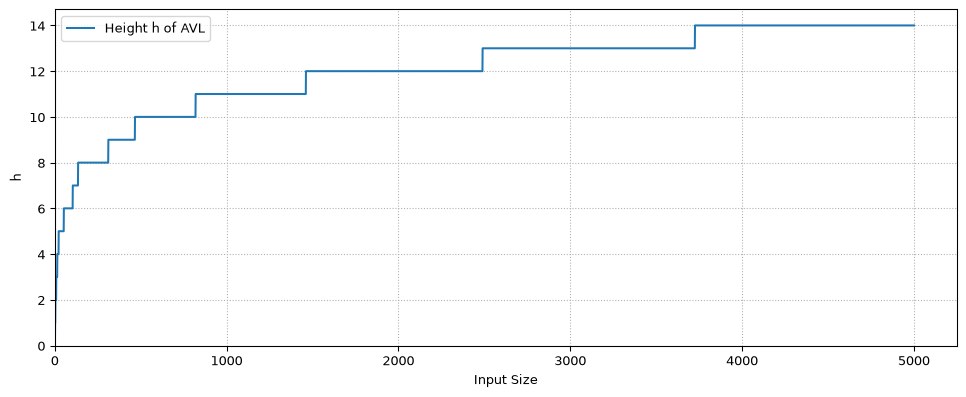

In [12]:
# Plotting the height of the AVL tree after each insertion
figure(figsize=(12, 4.5), dpi=97)

y = height_store[:]
x = [i+1 for i in range(len(y))]

# plt.subplot(3, 1, 2)
plt.plot(x, y, label="Height h of AVL")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')
plt.show()

# Q7

Compare AVL and BST search time

## BST Tree: All Code

In [13]:
iterations = 0 # Global Variable to count iterations during a run

In [14]:
class BST_Node:
    def __init__(self):
        self.lchild = None
        self.rchild = None
        self.value = None
        self.parent = None

def BST_Insert(value, root_node:BST_Node | None = None) -> BST_Node:
    assert value != None, "Value cannot be None"
    y = None
    x = root_node
    global iterations
    while x is not None:
        iterations += 1
        y = x
        if value == x.value: # type: ignore
            if PRINT_DEBUG:
                print(f"Value {value} already exists in the BST. Duplicate values are not allowed.")
            return root_node # type: ignore
        elif value < x.value: # type: ignore
            x = x.lchild # type: ignore
        else:
            x = x.rchild # type: ignore
    new_node = BST_Node()
    new_node.value = value
    new_node.parent = y # type: ignore
    if y is None:
        root_node = new_node
    elif value < y.value: # type: ignore
        y.lchild = new_node # type: ignore
    else:
        y.rchild = new_node # type: ignore
    return root_node # type: ignore

def BST_inorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    BST_inorder(root_node.lchild)
    print(root_node.value, end=',')
    BST_inorder(root_node.rchild)

def BST_preorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    print(root_node.value, end=',')
    BST_preorder(root_node.lchild)
    BST_preorder(root_node.rchild)

def BST_postorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    BST_postorder(root_node.lchild)
    BST_postorder(root_node.rchild)
    print(root_node.value, end=',')

def BST_Search(value, root_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if root_node is None:
        return None
    iterations += 1 # type: ignore
    if value == root_node.value:
        return root_node
    elif value < root_node.value:
        return BST_Search(value, root_node.lchild)
    else:
        return BST_Search(value, root_node.rchild)

## AVL Tree Searching Code

In [15]:
def AVL_Search(value, root_node: AVL_Node | None = None) -> AVL_Node | None:
    global iterations
    if root_node is None or root_node.value is None:
        return None
    iterations += 1 # type: ignore
    if value == root_node.value:
        return root_node
    elif value < root_node.value:
        return AVL_Search(value, root_node.lchild)
    else:
        return AVL_Search(value, root_node.rchild)

## Compare iterations for AVL_Search vs BST_Search

In [ ]:
def _deepest_avl_value(node: AVL_Node) -> int:
    # Cached height lets us walk straight to the deepest leaf in O(log n)
    while node.lchild is not None or node.rchild is not None:
        if node.lchild is None:
            node = node.rchild
        elif node.rchild is None:
            node = node.lchild
        elif node.lchild.height >= node.rchild.height:
            node = node.lchild
        else:
            node = node.rchild
    return node.value  # type: ignore


def _median_insertion_order(sorted_vals: list) -> list:
    # Median-first insertion forces the most balanced BST shape possible
    if not sorted_vals:
        return []
    mid = len(sorted_vals) // 2
    return (
        [sorted_vals[mid]]
        + _median_insertion_order(sorted_vals[:mid])
        + _median_insertion_order(sorted_vals[mid + 1:])
    )


def compare_search_iterations(n: int, arr1: list) -> tuple:
    global iterations

    assert isinstance(n, int) and n > 0, "n must be a positive integer"
    assert len(arr1) >= 5000, "arr1 must contain at least 5000 elements"
    assert n <= len(arr1), "n cannot exceed the length of arr1"

    start_idx = random.randint(0, len(arr1) - n)
    elements = arr1[start_idx : start_idx + n]

    # Main trees, built in sampled (effectively random) order
    bst_root = None
    for val in elements:
        bst_root = BST_Insert(val, bst_root)

    avl_root = None
    for val in elements:
        avl_root = AVL_insert(avl_root, val)

    # Sorted-order insertion forces the true BST worst case (degenerate chain)
    sorted_elements = sorted(set(elements))
    worst_bst_root = None
    for val in sorted_elements:
        worst_bst_root = BST_Insert(val, worst_bst_root)
    worst_bst_value = sorted_elements[-1]

    # Median-first insertion forces the most balanced BST possible (for reference)
    balanced_order = _median_insertion_order(sorted_elements)
    balanced_bst_root = None
    for val in balanced_order:
        balanced_bst_root = BST_Insert(val, balanced_bst_root)

    # Best case: root is always depth 0, regardless of insertion order
    best_bst_value = bst_root.value  # type: ignore
    best_avl_value = avl_root.value  # type: ignore

    # AVL worst case: rotations bound height to O(log n) regardless of order
    worst_avl_value = _deepest_avl_value(avl_root) # type: ignore

    # Random case: any element actually inserted into the main trees
    random_bst_value = random.choice(elements)
    random_avl_value = random.choice(elements)

    iterations = 0
    BST_Search(best_bst_value, bst_root)
    best_case_bst = iterations

    iterations = 0
    AVL_Search(best_avl_value, avl_root)
    best_case_avl = iterations

    iterations = 0
    BST_Search(worst_bst_value, worst_bst_root)  # searched in the sorted-order tree
    worst_case_bst = iterations

    iterations = 0
    AVL_Search(worst_avl_value, avl_root)
    worst_case_avl = iterations

    iterations = 0
    BST_Search(random_bst_value, bst_root)
    random_case_bst = iterations

    iterations = 0
    AVL_Search(random_avl_value, avl_root)
    random_case_avl = iterations

    return (
        best_case_bst, best_case_avl,
        worst_case_bst, worst_case_avl,
        random_case_bst, random_case_avl,
    )

In [17]:
import statistics

results = {}
trials = 10  # adjust as needed

for n in [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]:
    runs = [compare_search_iterations(n, arr1) for _ in range(trials)]

    best_case_bst  = min(run[0] for run in runs)
    best_case_avl  = min(run[1] for run in runs)
    worst_case_bst = max(run[2] for run in runs)
    worst_case_avl = max(run[3] for run in runs)
    random_case_bst = statistics.mean(run[4] for run in runs)
    random_case_avl = statistics.mean(run[5] for run in runs)

    results[n] = (
        best_case_bst, best_case_avl,
        worst_case_bst, worst_case_avl,
        random_case_bst, random_case_avl,
    )
print("Results:\n", results)

Results:
 {10: (1, 1, 10, 4, 4.2, 3), 25: (1, 1, 25, 6, 5, 4.3), 50: (1, 1, 50, 7, 5.3, 3.9), 100: (1, 1, 100, 8, 7.4, 5.8), 250: (1, 1, 250, 10, 9, 7.7), 500: (1, 1, 498, 11, 8.5, 8), 1000: (1, 1, 987, 12, 12.6, 9.6), 2500: (1, 1, 2420, 14, 27.2, 9.7), 5000: (1, 1, 4555, 15, 67.6, 10.6)}


In [18]:
search_columns = [
    "best_case_bst", "best_case_avl",
    "worst_case_bst", "worst_case_avl",
    "random_case_bst", "random_case_avl",
]

search_df = pd.DataFrame.from_dict(results, orient="index", columns=search_columns)
search_df.index.name = "n"
search_df = search_df.reset_index()

In [19]:
search_df

,n,best_case_bst,best_case_avl,worst_case_bst,worst_case_avl,random_case_bst,random_case_avl
0,10,1,1,10,4,4.2,3.0
1,25,1,1,25,6,5.0,4.3
2,50,1,1,50,7,5.3,3.9
3,100,1,1,100,8,7.4,5.8
4,250,1,1,250,10,9.0,7.7
5,500,1,1,498,11,8.5,8.0
6,1000,1,1,987,12,12.6,9.6
7,2500,1,1,2420,14,27.2,9.7
8,5000,1,1,4555,15,67.6,10.6


In [20]:
search_df.to_csv("2650026_lab3_data_search.csv", index=False)

# Q.

Delete an element from the array input from `input.txt`, and then store the new output in `output.txt`.

In [ ]:
def AVL_Delete(value, root_node: AVL_Node | None) -> AVL_Node | None:
    if root_node is None or root_node.value is None:
        print(f"Value {value} not found in the AVL tree.")
        return root_node

    if value < root_node.value:
        root_node.lchild = AVL_Delete(value, root_node.lchild)
    elif value > root_node.value:
        root_node.rchild = AVL_Delete(value, root_node.rchild)
    else:
        # root_node IS the node to delete
        if root_node.lchild is None or root_node.rchild is None:
            child = root_node.lchild if root_node.lchild is not None else root_node.rchild
            if child is not None:
                # Splice child past root_node. root_node.parent may still be a
                # real ancestor (if root_node is internal) or None (if root_node
                # is the true tree root) — both are correct values to copy here,
                # BEFORE root_node goes out of scope. Same "capture before
                # mutate" issue as OG_PARENT in the rotation functions: without
                # this line, child.parent would keep dangling-pointing at the
                # just-deleted root_node whenever root_node was the whole tree's
                # root (the one case with no enclosing setter to auto-fix it).
                child.parent = root_node.parent
            print(f"Deleted {root_node}, spliced in {child}")
            return child  # 0 or 1 child: caller's setter (or bare reassignment
                          # at the true root) takes it from here
        else:
            # 2 children: find in-order successor (leftmost node of right subtree)
            successor = root_node.rchild
            while successor.lchild is not None:
                successor = successor.lchild
            print(f"Replacing {root_node} with successor value {successor.value}")
            root_node.value = successor.value
            root_node.rchild = AVL_Delete(successor.value, root_node.rchild)

    # --- Rebalance, checked at EVERY level as recursion unwinds ---
    # Unlike insert, a single rotation here does NOT guarantee ancestors above
    # stay balanced — deletion can shrink a subtree's height, so this check has
    # to run at every returning frame, potentially cascading multiple rotations
    # all the way up to the root (O(log n) rotations in the worst case, vs. at
    # most 1 for insert).
    root_node.update_height_and_balance()

    if root_node.balance_factor == 2:
        # child's bf uses >= 0 (not > 0 like insert) because deletion can leave
        # the taller child PERFECTLY balanced (bf == 0), which still requires a
        # single rotation, not a double one — insert can never produce that
        # exact situation, which is why this threshold differs from insert's.
        if root_node.lchild.balance_factor >= 0: # type: ignore
            root_node = AVL_right_rotate(root_node, root_node)          # LL
        else:
            root_node = AVL_double_rotate_right(root_node, root_node)  # LR
    elif root_node.balance_factor == -2:
        if root_node.rchild.balance_factor <= 0: # type: ignore
            root_node = AVL_left_rotate(root_node, root_node)           # RR
        else:
            root_node = AVL_double_rotate_left(root_node, root_node)   # RL

    return root_node

In [ ]:
root0 = AVL_Delete(77, root0)
AVL_inorder_traversal(root0, out_file = "output1.txt")